## Introducción

Durante las últimas dos décadas, el mundo ha experimentado una digitalización sin precedentes. El acceso a internet ha dejado de ser un lujo para convertirse en una necesidad básica. Sin embargo, esta hiperconectividad ha traído consigo efectos secundarios no previstos en la salud pública. 

El presente proyecto analiza la adopción masiva de internet, la dependencia de dispositivos móviles (smartphones) y el impacto perjudicial en la salud mental de la población, utilizando a España como caso de estudio analítico.

## Objetivo del analisis

General
1. Analizar los datos entre el crecimiento del acceso a internet, el uso intensivo de smartphones y la evolución de indicadores de salud mental en España. Periodo 2004 a 2017

Especifico

1. Evaluar crecimiento de internet

2. Analizar tendencias de salud mental

3. Explorar impacto del uso de smartphones


## Primera parte del proyecto

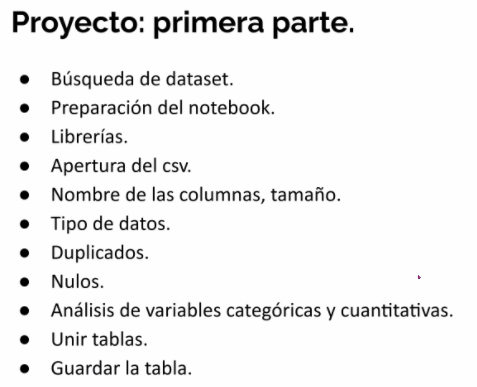

Link repo (privado): https://github.com/mnahuelanca/Proyecto-Salud-Mental

## Preguntas

1. ¿Existe relación entre la digitalización (internet + smartphones) y la salud mental?
2. ¿Los años con mayor conectividad presentan mayores niveles de depresión o ansiedad?
3. ¿El crecimiento de internet coincide temporalmente con cambios en las busquedas de salud mental?
4. ¿El uso intensivo del smartphone está asociado con mayores niveles de estrés?

## Librerias


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import plotly.express 
print("Librerias importadas correctamente")

Librerias importadas correctamente


## Importar datos

### 1. Acceso a Internet en hogares globales (2000-2025): 

 Este conjunto de datos recopila información sobre el acceso a internet en hogares a nivel mundial, cubriendo más de 200 países entre los años 2000 y 2025.

Los datos provienen de organismos como la Unión Internacional de Telecomunicaciones (UIT) y el Banco Mundial.



 Link: https://www.kaggle.com/datasets/muhammadimran76/global-household-internet-access-dataset-2000-25


In [2]:
dfInternet = pd.read_csv('./Data/InternetAccess.csv')
dfInternet.head()

,country_code,country_name,year,internet_access_pct,decade,access_category,high_access
0,AFG,Afghanistan,2002,0.05,2000s,Low (<25%),0
1,AFG,Afghanistan,2003,0.30,2000s,Low (<25%),0
2,AFG,Afghanistan,2004,0.55,2000s,Low (<25%),0
3,AFG,Afghanistan,2005,0.75,2000s,Low (<25%),0
4,AFG,Afghanistan,2006,0.90,2000s,Low (<25%),0


* country_name: Nombre del pais
* country_code: Código de 3 letras del país
* year: Año de la medición
* internet_access_pct: Porcentaje de hogares con acceso a internet
* decade: Década a la que pertenece el año
* access_category: Clasificación del nivel de acceso a internet según el porcentaje
    - Low < 25%
    - Medium < 25-60% 
    - High > 60%
* high_access: Variable binaria.
    - 1 = Alto acceso a internet
    - 0 = No es alto acceso



In [3]:
dfInternet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4109 entries, 0 to 4108
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country_code         4109 non-null   object 
 1   country_name         4109 non-null   object 
 2   year                 4109 non-null   int64  
 3   internet_access_pct  4109 non-null   float64
 4   decade               4109 non-null   object 
 5   access_category      4109 non-null   object 
 6   high_access          4109 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 224.8+ KB


In [4]:
dfInternet.shape

(4109, 7)

In [5]:
# Verificar valores duplicados en dfInternet
duplicados = dfInternet.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados}")

Total de filas duplicadas: 0


In [6]:
# Verificar valores nulos en dfInternet
print("Valores nulos por columna:")
print(dfInternet.isnull().sum())

Valores nulos por columna:
country_code           0
country_name           0
year                   0
internet_access_pct    0
decade                 0
access_category        0
high_access            0
dtype: int64


In [7]:
dfInternet['decade'].unique()

array(['2000s', '2010s', '2020s'], dtype=object)

In [8]:
dfInternet['access_category'].unique()

array(['Low (<25%)', 'Medium (25-60%)', 'High (>60%)'], dtype=object)

In [9]:
dfInternet['country_name'].nunique() # Cantidad de valores unicos en PAISES

222

In [10]:
dfInternet.country_name.value_counts() # Cantidad de valores por pais

country_name
Austria                         26
Denmark                         26
Switzerland                     26
Chile                           25
Hungary                         25
                                ..
Somalia, Federal Republic of     1
Sint Maarten (Dutch part)        1
Tokelau (NZ)                     1
Wallis-et-Futuna (Fr.)           1
Virgin Islands (U.S.)            1
Name: count, Length: 222, dtype: int64

### 1.1 Acceso a internet España

In [11]:
# Df solo con resultado de España
dfESinternet = dfInternet[dfInternet['country_name'] == 'Spain']
dfESinternet.rename(columns={'year': 'Year', 'internet_access_pct': 'Internet_Access_%'}, inplace=True)
dfESinternet.head(23)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19732\3120096570.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfESinternet.rename(columns={'year': 'Year', 'internet_access_pct': 'Internet_Access_%'}, inplace=True)


,country_code,country_name,Year,Internet_Access_%,decade,access_category,high_access
3372,ESP,Spain,2002,17.40,2000s,Low (<25%),0
3373,ESP,Spain,2003,27.55,2000s,Medium (25-60%),0
3374,ESP,Spain,2004,33.64,2000s,Medium (25-60%),0
3375,ESP,Spain,2005,35.51,2000s,Medium (25-60%),0
3376,ESP,Spain,2006,39.08,2000s,Medium (25-60%),0
3377,ESP,Spain,2007,44.63,2000s,Medium (25-60%),0
3378,ESP,Spain,2008,51.05,2000s,Medium (25-60%),0
3379,ESP,Spain,2009,53.96,2000s,Medium (25-60%),0
3380,ESP,Spain,2010,59.10,2010s,Medium (25-60%),0
3381,ESP,Spain,2011,63.88,2010s,High (>60%),1


In [12]:
dfESinternet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 3372 to 3394
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country_code       23 non-null     object 
 1   country_name       23 non-null     object 
 2   Year               23 non-null     int64  
 3   Internet_Access_%  23 non-null     float64
 4   decade             23 non-null     object 
 5   access_category    23 non-null     object 
 6   high_access        23 non-null     int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 1.4+ KB


In [13]:
dfESinternet.Year.unique

<bound method Series.unique of 3372    2002
3373    2003
3374    2004
3375    2005
3376    2006
3377    2007
3378    2008
3379    2009
3380    2010
3381    2011
3382    2012
3383    2013
3384    2014
3385    2015
3386    2016
3387    2017
3388    2018
3389    2019
3390    2020
3391    2021
3392    2022
3393    2023
3394    2024
Name: Year, dtype: int64>

In [14]:
# Nos quedamos con las columnas que nos interesan.
dfESinternet = dfESinternet[['Year', 'Internet_Access_%', 'access_category']]
dfESinternet

,Year,Internet_Access_%,access_category
3372,2002,17.40,Low (<25%)
3373,2003,27.55,Medium (25-60%)
3374,2004,33.64,Medium (25-60%)
3375,2005,35.51,Medium (25-60%)
3376,2006,39.08,Medium (25-60%)
3377,2007,44.63,Medium (25-60%)
3378,2008,51.05,Medium (25-60%)
3379,2009,53.96,Medium (25-60%)
3380,2010,59.10,Medium (25-60%)
3381,2011,63.88,High (>60%)


### 2. Tendencias globales sobre salud mental:

Este conjunto de datos contiene datos informativos de países de todo el mundo sobre la prevalencia de trastornos de salud mental, incluyendo esquizofrenia, trastorno bipolar, trastornos alimentarios, trastornos de ansiedad, trastornos por consumo de drogas, depresión y trastornos por consumo de alcohol.

Link: https://www.kaggle.com/datasets/thedevastator/uncover-global-trends-in-mental-health-disorder?select=Mental+health+Depression+disorder+Data.csv

In [15]:
dfSaludMental = pd.read_csv('./Data/MentalHealth.csv')
dfSaludMental.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19732\3242199635.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  dfSaludMental = pd.read_csv('./Data/MentalHealth.csv')


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260


* Entity: Nombre del país
* Code: Código del país
* Year: Año de la medición
* Schizophrenia (%): Porcentaje de la población con esquizofrenia
* Bipolar disorder (%): Porcentaje con trastorno bipolar
* Eating disorders (%): Porcentaje con trastornos alimenticios
* Anxiety disorders (%): Porcentaje con trastornos de ansiedad
* Drug use disorders (%): Porcentaje con trastornos por consumo de drogas
* Depression (%): Porcentaje de la población con depresión
* Alcohol use disorders (%): Porcentaje con trastornos por consumo de alcohol

In [16]:
dfSaludMental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108553 entries, 0 to 108552
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   index                      108553 non-null  int64  
 1   Entity                     108553 non-null  object 
 2   Code                       103141 non-null  object 
 3   Year                       108553 non-null  object 
 4   Schizophrenia (%)          25875 non-null   object 
 5   Bipolar disorder (%)       19406 non-null   object 
 6   Eating disorders (%)       100236 non-null  object 
 7   Anxiety disorders (%)      6468 non-null    float64
 8   Drug use disorders (%)     6468 non-null    float64
 9   Depression (%)             6468 non-null    float64
 10  Alcohol use disorders (%)  6468 non-null    float64
dtypes: float64(4), int64(1), object(6)
memory usage: 9.1+ MB


In [17]:
dfSaludMental.shape

(108553, 11)

In [18]:
# Verificar valores duplicados en dfSaludMental
duplicados2 = dfSaludMental.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados2}")

Total de filas duplicadas: 0


In [19]:
# Verificar valores nulos en dfSaludMental
print("Valores nulos por columna:")
print(dfSaludMental.isnull().sum())

Valores nulos por columna:
index                             0
Entity                            0
Code                           5412
Year                              0
Schizophrenia (%)             82678
Bipolar disorder (%)          89147
Eating disorders (%)           8317
Anxiety disorders (%)        102085
Drug use disorders (%)       102085
Depression (%)               102085
Alcohol use disorders (%)    102085
dtype: int64


### 2.1 Salud mental España

In [20]:
# Df solo con resultado de España
dfESPSalud = dfSaludMental[dfSaludMental['Entity'] == 'Spain']
dfESPSalud.head(40)

,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
5376,5376,Spain,ESP,1990,0.27954,0.955625,0.57438,5.071231,1.164410,3.858486,0.821985
5377,5377,Spain,ESP,1991,0.279954,0.956914,0.582375,5.077642,1.161271,3.789711,0.820276
5378,5378,Spain,ESP,1992,0.280331,0.958117,0.590314,5.083708,1.163508,3.724554,0.819173
5379,5379,Spain,ESP,1993,0.280663,0.959197,0.597923,5.089085,1.167541,3.669752,0.818741
5380,5380,Spain,ESP,1994,0.280945,0.960107,0.604526,5.093438,1.174702,3.631979,0.818897
5381,5381,Spain,ESP,1995,0.281177,0.960854,0.611023,5.096872,1.182115,3.613517,0.819615
5382,5382,Spain,ESP,1996,0.281255,0.961072,0.61661,5.088122,1.198150,3.596280,0.821655
5383,5383,Spain,ESP,1997,0.281135,0.960627,0.622586,5.062915,1.230010,3.563349,0.825072
5384,5384,Spain,ESP,1998,0.28092,0.959808,0.628657,5.031104,1.269936,3.525654,0.829022
5385,5385,Spain,ESP,1999,0.280698,0.958877,0.635242,5.002221,1.308583,3.489747,0.832520


In [21]:
# Valores nulos específicamente en España
print("Valores nulos en dfESPSalud por columna:")
print(dfESPSalud.isnull().sum())
print("\n" + "="*50 + "\n")

# Filas con valores nulos en España
print(f"Total de filas en España: {len(dfESPSalud)}")
print(f"Filas con al menos un valor nulo en España: {dfESPSalud.isnull().any(axis=1).sum()}")

Valores nulos en dfESPSalud por columna:
index                          0
Entity                         0
Code                           0
Year                           0
Schizophrenia (%)            384
Bipolar disorder (%)         412
Eating disorders (%)          28
Anxiety disorders (%)        468
Drug use disorders (%)       468
Depression (%)               468
Alcohol use disorders (%)    468
dtype: int64


Total de filas en España: 496
Filas con al menos un valor nulo en España: 468


Encontramos muchas valores vacios, ya que el dataframe, ademas de tener los porcentajes de cada enfermedad, tiene la poblacion historica de cada pais. Dejando asi, las otras celdas en NaN.

In [22]:
cols_pct = [
    'Schizophrenia (%)',
    'Bipolar disorder (%)',
    'Eating disorders (%)',
    'Anxiety disorders (%)',
    'Drug use disorders (%)',
    'Depression (%)',
    'Alcohol use disorders (%)'
]

dfESPSalud = dfESPSalud.dropna(subset=cols_pct)

In [23]:
dfESPSalud.head(40)

,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
5376,5376,Spain,ESP,1990,0.27954,0.955625,0.57438,5.071231,1.164410,3.858486,0.821985
5377,5377,Spain,ESP,1991,0.279954,0.956914,0.582375,5.077642,1.161271,3.789711,0.820276
5378,5378,Spain,ESP,1992,0.280331,0.958117,0.590314,5.083708,1.163508,3.724554,0.819173
5379,5379,Spain,ESP,1993,0.280663,0.959197,0.597923,5.089085,1.167541,3.669752,0.818741
5380,5380,Spain,ESP,1994,0.280945,0.960107,0.604526,5.093438,1.174702,3.631979,0.818897
5381,5381,Spain,ESP,1995,0.281177,0.960854,0.611023,5.096872,1.182115,3.613517,0.819615
5382,5382,Spain,ESP,1996,0.281255,0.961072,0.61661,5.088122,1.198150,3.596280,0.821655
5383,5383,Spain,ESP,1997,0.281135,0.960627,0.622586,5.062915,1.230010,3.563349,0.825072
5384,5384,Spain,ESP,1998,0.28092,0.959808,0.628657,5.031104,1.269936,3.525654,0.829022
5385,5385,Spain,ESP,1999,0.280698,0.958877,0.635242,5.002221,1.308583,3.489747,0.832520


In [24]:
dfESPSalud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 5376 to 5403
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      28 non-null     int64  
 1   Entity                     28 non-null     object 
 2   Code                       28 non-null     object 
 3   Year                       28 non-null     object 
 4   Schizophrenia (%)          28 non-null     object 
 5   Bipolar disorder (%)       28 non-null     object 
 6   Eating disorders (%)       28 non-null     object 
 7   Anxiety disorders (%)      28 non-null     float64
 8   Drug use disorders (%)     28 non-null     float64
 9   Depression (%)             28 non-null     float64
 10  Alcohol use disorders (%)  28 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 2.6+ KB


Ahora, vemos que tenemos columnas tipo "object" cuando deberian ser numericas. Las convertimos.

In [25]:
cols_pct = [
    'Schizophrenia (%)',
    'Bipolar disorder (%)',
    'Eating disorders (%)',
    'Anxiety disorders (%)',
    'Drug use disorders (%)',
    'Depression (%)',
    'Alcohol use disorders (%)'
]

dfESPSalud[cols_pct] = dfESPSalud[cols_pct].apply(pd.to_numeric, errors='coerce')

In [26]:
dfESPSalud['Year'] = pd.to_numeric(dfESPSalud['Year'], errors='coerce')

In [27]:
dfESPSalud.describe()

,index,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,5389.500000,2003.500000,0.280540,0.968674,0.664637,5.134692,1.339278,3.516501,0.854179
std,8.225975,8.225975,0.000459,0.008824,0.053164,0.108139,0.111111,0.126794,0.033425
min,5376.000000,1990.000000,0.279540,0.955625,0.574380,4.986628,1.161271,3.358963,0.818741
25%,5382.750000,1996.750000,0.280240,0.960004,0.621092,5.059849,1.222045,3.436526,0.824300
50%,5389.500000,2003.500000,0.280513,0.973776,0.661029,5.091261,1.405653,3.485314,0.836967
75%,5396.250000,2010.250000,0.280831,0.976747,0.720603,5.271389,1.423579,3.571582,0.891875
max,5403.000000,2017.000000,0.281539,0.978228,0.733379,5.280279,1.468868,3.858486,0.904203


In [28]:
dfESPSalud['Year'].unique

<bound method Series.unique of 5376    1990
5377    1991
5378    1992
5379    1993
5380    1994
5381    1995
5382    1996
5383    1997
5384    1998
5385    1999
5386    2000
5387    2001
5388    2002
5389    2003
5390    2004
5391    2005
5392    2006
5393    2007
5394    2008
5395    2009
5396    2010
5397    2011
5398    2012
5399    2013
5400    2014
5401    2015
5402    2016
5403    2017
Name: Year, dtype: int64>

In [29]:
# Me quedo con las columnas que me interesan.
dfESPSalud = dfESPSalud[['Year', 'Schizophrenia (%)', 'Bipolar disorder (%)', 'Eating disorders (%)', 'Anxiety disorders (%)', 'Drug use disorders (%)', 'Depression (%)', 'Alcohol use disorders (%)']]
dfESPSalud

,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
5376,1990,0.279540,0.955625,0.574380,5.071231,1.164410,3.858486,0.821985
5377,1991,0.279954,0.956914,0.582375,5.077642,1.161271,3.789711,0.820276
5378,1992,0.280331,0.958117,0.590314,5.083708,1.163508,3.724554,0.819173
5379,1993,0.280663,0.959197,0.597923,5.089085,1.167541,3.669752,0.818741
5380,1994,0.280945,0.960107,0.604526,5.093438,1.174702,3.631979,0.818897
5381,1995,0.281177,0.960854,0.611023,5.096872,1.182115,3.613517,0.819615
5382,1996,0.281255,0.961072,0.616610,5.088122,1.198150,3.596280,0.821655
5383,1997,0.281135,0.960627,0.622586,5.062915,1.230010,3.563349,0.825072
5384,1998,0.280920,0.959808,0.628657,5.031104,1.269936,3.525654,0.829022
5385,1999,0.280698,0.958877,0.635242,5.002221,1.308583,3.489747,0.832520


////////////////////////

### 3. Análisis de uso y adicción de smartphones:


Este dataframe recopila información sobre el uso de smartphones y niveles de adicción en usuarios individuales.

(Se analiza por separado. Actuará como un modelo transversal sobre el analisis del estres)

Link: https://www.kaggle.com/datasets/zahranusratt/smartphone-usage-and-addiction-analysis-dataset

In [30]:
dfTelefono = pd.read_csv('./Data/SmartphoneAddiction.csv')
dfTelefono.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


* User_ID: Identificador único del usuario.
* Age: Edad del usuario.
* Gender: Género del usuario.
* Daily_Screen_Time_Hours: Horas totales de uso del celular por día.
* Social_Media_Hours: Tiempo diario en redes sociales.
* Gaming_Hours: Tiempo diario en juegos.
* Work_Study_Hours: Uso del celular para trabajo o estudio.
* Notifications_Per_Day: Cantidad de notificaciones recibidas por día.
* App_Opens_Per_Day: Cantidad de veces que se abren apps diariamente.
* Weekend_screen_time: Cantidad de horas de uso del smartphone durante los fin de semana.
* Sleep_Hours: Horas de sueño por día.
* Stress_Level: Nivel de estrés (bajo, medio, alto).
* Academic_Work_Impact: Indica si el uso del celular afecta el rendimiento. (si/No)
* Addiction_Level: Nivel de adicción.
* Addicted_Label: Variable binaria
    - 1 → adicto
    - 0 → no adicto

In [31]:
dfTelefono.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [32]:
dfTelefono.shape

(7500, 16)

### 4. Busquedas relacionadas a la salud mental España (2004-2025)

Este dataset sobre tendencias de búsqueda en salud mental en España (2004–2025) recopila datos sobre la frecuencia o interés de búsqueda en internet relacionado con temas de salud mental.

Como tiene formato de fecha mensual (ej. 2004-03-01), agruparé los datos para sacar el promedio anual. Así podremos unirla a las tablas 1 y 2 por Año.

Las busquedas fueron extraidas de Google Trends. Incluye:

-Ansiedad

-Depresión

-Estrés

-Ataques de pánico

-Terapia online

Periodo: 2004–2025 / Frecuencia: mensual / Son índices de interés de búsqueda.

Interes relativo de busqueda: Es una medida que indica qué tan popular es una búsqueda en comparación con otras en distintos momentos del tiempo. Te dice qué tan importante fue ese tema en ese momento. (0 - 100)

Link: https://www.kaggle.com/datasets/wildina/mental-health-search-trends-in-spain-20042025/data

In [33]:
dfEspBusquedas = pd.read_csv('./Data/MentalHealthSpain.csv')
dfEspBusquedas.head()

,date,anxiety,depression,online_therapy,panic_attacks,stress,anxiety_diff,online_diff
0,2004-03-01,41,73,0,41,35,-2.0,0.0
1,2004-04-01,45,84,0,50,40,4.0,0.0
2,2004-05-01,44,83,0,34,43,-1.0,0.0
3,2004-06-01,44,79,0,41,30,0.0,0.0
4,2004-07-01,46,74,0,44,28,2.0,0.0


In [34]:
# Asegurarnos de que la columna date sea tipo datetime
dfEspBusquedas['date'] = pd.to_datetime(dfEspBusquedas['date'])

# Extraer el año
dfEspBusquedas['Year'] = dfEspBusquedas['date'].dt.year

# Agrupar por año y sacar el promedio de interés de búsqueda
dfEspBusquedaAnual = dfEspBusquedas.groupby('Year')[['anxiety', 'depression', 'online_therapy', 'panic_attacks', 'stress']].mean().reset_index()

# Redondear los valores para que sea más limpio
dfEspBusquedaAnual = dfEspBusquedaAnual.round(2)
dfEspBusquedaAnual.head(22)

,Year,anxiety,depression,online_therapy,panic_attacks,stress
0,2004,44.60,79.90,0.00,39.90,33.40
1,2005,40.92,73.50,0.00,43.42,31.50
2,2006,36.50,67.92,0.00,42.25,27.58
3,2007,34.75,62.83,0.00,37.83,26.25
4,2008,33.58,59.58,9.00,34.33,26.83
5,2009,33.00,56.83,39.42,36.83,25.42
6,2010,32.75,56.42,43.08,38.83,26.75
7,2011,34.50,54.42,58.83,42.17,27.92
8,2012,36.83,50.92,49.00,43.33,26.58
9,2013,40.67,53.17,51.75,45.00,27.42


* year: Año de busqueda
* anxiety: Nivel relativo de búsquedas sobre ansiedad
* depression: Nivel relativo de búsquedas sobre depresión
* online_therapy: Interés en terapia online
* panic_attacks: Nivel relativo de búsquedas sobre ataques de pánico
* stress: Nivel relativo de búsquedas sobre estres

In [35]:
dfEspBusquedaAnual.describe()

,Year,anxiety,depression,online_therapy,panic_attacks,stress
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,2014.500000,52.943636,68.799091,43.712273,52.953636,36.460909
std,6.493587,17.777837,10.765238,25.948146,14.820206,10.939525
min,2004.000000,32.750000,50.920000,0.000000,34.330000,25.420000
25%,2009.250000,36.582500,59.915000,37.477500,42.190000,27.460000
50%,2014.500000,49.210000,70.170000,50.375000,50.040000,30.875000
75%,2019.750000,68.687500,77.732500,60.210000,63.920000,43.207500
max,2025.000000,85.000000,87.830000,75.920000,88.670000,58.580000


In [36]:
# Verificar valores nulos en dfEspBusquedaAnual
print("Valores nulos por columna en dfEspBusquedaAnual:")
print(dfEspBusquedaAnual.isnull().sum())
print("\n" + "="*50 + "\n")
print(f"Total de filas: {len(dfEspBusquedaAnual)}")
print(f"Filas con al menos un valor nulo: {dfEspBusquedaAnual.isnull().any(axis=1).sum()}")

Valores nulos por columna en dfEspBusquedaAnual:
Year              0
anxiety           0
depression        0
online_therapy    0
panic_attacks     0
stress            0
dtype: int64


Total de filas: 22
Filas con al menos un valor nulo: 0


## Unimos datos

In [37]:
inicio = 2004
fin = 2017

dfESinternet = dfESinternet[(dfESinternet['Year'] >= inicio) & (dfESinternet['Year'] <= fin)]
dfESPSalud = dfESPSalud[(dfESPSalud['Year'] >= inicio) & (dfESPSalud['Year'] <= fin)]
dfEspBusquedaAnual = dfEspBusquedaAnual[(dfEspBusquedaAnual['Year'] >= inicio) & (dfEspBusquedaAnual['Year'] <= fin)]

In [38]:
dfFinal= dfESinternet.merge(dfESPSalud, on='Year', how='inner')
dfFinal = dfFinal.merge(dfEspBusquedaAnual, on='Year', how='inner')

In [39]:
# Cambio el nombre de las columnas
dfFinal = dfFinal.rename(columns={
    'Year': 'anio',
    'Internet_Access_%': 'acceso_internet_pct',
    'access_category': 'categoria_acceso_internet',
    'Schizophrenia (%)': 'esquizofrenia_pct',
    'Bipolar disorder (%)': 'trastorno_bipolar_pct',
    'Eating disorders (%)': 'trastornos_alimenticios_pct',
    'Anxiety disorders (%)': 'trastornos_ansiedad_pct',
    'Drug use disorders (%)': 'trastornos_drogas_pct',
    'Depression (%)': 'depresion_pct',
    'Alcohol use disorders (%)': 'trastornos_alcohol_pct',
    'anxiety': 'busquedas_ansiedad',
    'depression': 'busquedas_depresion',
    'online_therapy': 'busquedas_terapia_online',
    'panic_attacks': 'busquedas_ataques_panico',
    'stress': 'busquedas_estres'
})

In [40]:
dfFinal.head(25)

,anio,acceso_internet_pct,categoria_acceso_internet,esquizofrenia_pct,trastorno_bipolar_pct,trastornos_alimenticios_pct,trastornos_ansiedad_pct,trastornos_drogas_pct,depresion_pct,trastornos_alcohol_pct,busquedas_ansiedad,busquedas_depresion,busquedas_terapia_online,busquedas_ataques_panico,busquedas_estres
0,2004,33.64,Medium (25-60%),0.280481,0.976321,0.664298,5.050650,1.418556,3.373110,0.837303,44.60,79.90,0.00,39.90,33.40
1,2005,35.51,Medium (25-60%),0.280452,0.978228,0.670521,5.076251,1.428014,3.358963,0.838729,40.92,73.50,0.00,43.42,31.50
2,2006,39.08,Medium (25-60%),0.280388,0.977790,0.679390,5.111356,1.428885,3.362961,0.846888,36.50,67.92,0.00,42.25,27.58
3,2007,44.63,Medium (25-60%),0.280272,0.977331,0.690880,5.161165,1.422732,3.386968,0.863536,34.75,62.83,0.00,37.83,26.25
4,2008,51.05,Medium (25-60%),0.280144,0.976919,0.702688,5.212750,1.414858,3.416201,0.882636,33.58,59.58,9.00,34.33,26.83
5,2009,53.96,Medium (25-60%),0.280047,0.976659,0.712882,5.253633,1.408406,3.441262,0.898174,33.00,56.83,39.42,36.83,25.42
6,2010,59.10,Medium (25-60%),0.280010,0.976577,0.719542,5.271059,1.408640,3.454534,0.904203,32.75,56.42,43.08,38.83,26.75
7,2011,63.88,High (>60%),0.280047,0.976612,0.723788,5.272378,1.412485,3.460590,0.903373,34.50,54.42,58.83,42.17,27.92
8,2012,67.87,High (>60%),0.280139,0.976649,0.726458,5.274071,1.417659,3.470575,0.902213,36.83,50.92,49.00,43.33,26.58
9,2013,69.73,High (>60%),0.280297,0.976705,0.729313,5.275748,1.426120,3.480882,0.900545,40.67,53.17,51.75,45.00,27.42


## Exportamos tabla

In [41]:
dfFinal.to_csv('dfFinalEspana.csv', index=False)

dfEspana = pd.read_csv('dfFinalEspana.csv')
dfEspana.head(14)

,anio,acceso_internet_pct,categoria_acceso_internet,esquizofrenia_pct,trastorno_bipolar_pct,trastornos_alimenticios_pct,trastornos_ansiedad_pct,trastornos_drogas_pct,depresion_pct,trastornos_alcohol_pct,busquedas_ansiedad,busquedas_depresion,busquedas_terapia_online,busquedas_ataques_panico,busquedas_estres
0,2004,33.64,Medium (25-60%),0.280481,0.976321,0.664298,5.050650,1.418556,3.373110,0.837303,44.60,79.90,0.00,39.90,33.40
1,2005,35.51,Medium (25-60%),0.280452,0.978228,0.670521,5.076251,1.428014,3.358963,0.838729,40.92,73.50,0.00,43.42,31.50
2,2006,39.08,Medium (25-60%),0.280388,0.977790,0.679390,5.111356,1.428885,3.362961,0.846888,36.50,67.92,0.00,42.25,27.58
3,2007,44.63,Medium (25-60%),0.280272,0.977331,0.690880,5.161165,1.422732,3.386968,0.863536,34.75,62.83,0.00,37.83,26.25
4,2008,51.05,Medium (25-60%),0.280144,0.976919,0.702688,5.212750,1.414858,3.416201,0.882636,33.58,59.58,9.00,34.33,26.83
5,2009,53.96,Medium (25-60%),0.280047,0.976659,0.712882,5.253633,1.408406,3.441262,0.898174,33.00,56.83,39.42,36.83,25.42
6,2010,59.10,Medium (25-60%),0.280010,0.976577,0.719542,5.271059,1.408640,3.454534,0.904203,32.75,56.42,43.08,38.83,26.75
7,2011,63.88,High (>60%),0.280047,0.976612,0.723788,5.272378,1.412485,3.460590,0.903373,34.50,54.42,58.83,42.17,27.92
8,2012,67.87,High (>60%),0.280139,0.976649,0.726458,5.274071,1.417659,3.470575,0.902213,36.83,50.92,49.00,43.33,26.58
9,2013,69.73,High (>60%),0.280297,0.976705,0.729313,5.275748,1.426120,3.480882,0.900545,40.67,53.17,51.75,45.00,27.42


## Graficos 

...

In [42]:
# def graficos_eda_categoricos(cat):

#     #Calculamos el número de filas que necesitamos
#     from math import ceil
#     filas = ceil(cat.shape[1] / 2)

#     #Definimos el gráfico
#     f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

#     #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
#     ax = ax.flat 

#     #Creamos el bucle que va añadiendo gráficos
#     for cada, variable in enumerate(cat):
#         cat[variable].value_counts().plot.barh(ax = ax[cada])
#         ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
#         ax[cada].tick_params(labelsize = 12)

## Información relacionada 

1. El uso problemático del teléfono móvil: análisis transversal del perfil individual y los factores asociados -> https://pmc.ncbi.nlm.nih.gov/articles/PMC10560524/

2. Los efectos de los smartphones en el bienestar: integración teórica y agenda de investigación -> https://arxiv.org/abs/2005.09100

3. Adicción al teléfono móvil y conductas suicidas en adolescentes: estudio transversal escolar en la provincia de Zhejiang, China -> https://www.jmir.org/2025/1/e80410

4. Nuevo informe sobre el impacto de la tecnología en la infancia y la adolescencia -> https://www.unicef.es/noticia/nuevo-informe-sobre-el-impacto-de-la-tecnologia-en-la-infancia-y-la-adolescencia

5. Impacto del aumento del uso de Internet y las redes sociales en la salud mental de jóvenes y adolescentes -> https://www.ontsi.es/sites/ontsi/files/2023-10/policybriefredesocialesaludmentaljovenesyadolescentes.pdf

### Noticias relacionadas

1. Informe del forense sobre el suicidio de una estudiante en el Reino Unido pide regulación en las redes sociales -> https://techcrunch.com/2022/10/14/molly-russell-coroner-report/?guce_referrer=aHR0cHM6Ly93d3cuYmluZy5jb20v&guce_referrer_sig=AQAAABXyJnVYDIZY8bAKNKpJOEGZjBWjnuV6LOqeCInmCygyWNMtPr5R1icc5g2O-S0YlGkbdV7RErt3EZXxehuFhBpodLFjpxnjgrd5uGrGIqnA0NGUTXUwY7zJahl5I3R5o5iWukN62I8QaH5hQu9BXko8wWx8mTzEDS_095L10QXu&_guc_consent_skip=1680521666

2. Uso excesivo de pantallas, una ‘epidemia’ de salud mental en los más jóvenes -> https://www.agenciasinc.es/Reportajes/Uso-excesivo-de-pantallas-una-epidemia-de-salud-mental-en-los-mas-jovenes

3. La restricción del uso del celular en menores favorece la salud emocional -> https://www.infobae.com/salud/ciencia/2026/04/10/la-restriccion-del-uso-del-celular-en-menores-favorece-la-salud-emocional/

4. Massachusetts avanza con un proyecto para prohibir redes sociales a menores de 14 años y restringir celulares en escuelas -> https://www.infobae.com/estados-unidos/2026/04/08/massachusetts-avanza-con-un-proyecto-para-prohibir-redes-sociales-a-menores-de-14-anos-y-restringir-celulares-en-escuelas/

5. Estas son las enfermedades asociadas al uso de celulares en niños -> https://www.infobae.com/peru/2025/12/02/estas-son-las-enfermedades-asociadas-al-uso-de-celulares-en-ninos/

6. Los smartphones provocan 'pensamientos suicidas, baja autoestima y agresividad' en niños menores de 13 años, según un estudio -> https://www.euronews.com/health/2025/07/22/smartphones-lead-to-suicidal-thoughts-low-self-worth-and-aggression-in-children-under-13-s

### Libro relacionado

La generación ansiosa (Jonathan Haidt): Por qué las redes sociales están causando una epidemia de enfermedades mentales entre nuestros jóvenes

## Conclusiones finales

...

La IA puede ser otro proceso similar o influir de otra manera?

https://www.bloomberglinea.com/tecnologia/innovacion/google-anade-herramientas-de-salud-mental-al-chatbot-gemini-tras-una-demanda/

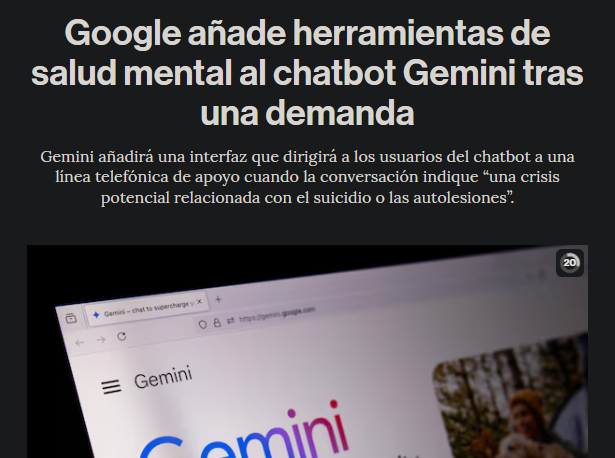